In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import warnings

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

In [3]:
RECORD_ID = '100'

FS = 360

TEST_SIZE = 0.3

print("Using record:", RECORD_ID)

Using record: 100


In [4]:
record = wfdb.rdrecord(
    RECORD_ID,
    pn_dir='mitdb'
)

annotation = wfdb.rdann(
    RECORD_ID,
    'atr',
    pn_dir='mitdb'
)

print("Record loaded successfully")

Record loaded successfully


In [5]:
r_peaks = annotation.sample

rr_intervals = np.diff(r_peaks) / FS

heart_rate = 60 / rr_intervals

print("Total HR samples:", len(heart_rate))

Total HR samples: 2273


In [6]:
df = pd.DataFrame({
    'heart_rate': heart_rate
})

df.loc[
    (df['heart_rate'] < 40) |
    (df['heart_rate'] > 180),
    'heart_rate'
] = np.nan

df['heart_rate'] = df['heart_rate'].interpolate(
    method='linear',
    limit_direction='both'
)

df['heart_rate'] = df['heart_rate'].rolling(
    window=3,
    center=True,
    min_periods=1
).mean()

df = df.dropna()

print("Clean samples:", len(df))

Clean samples: 2273


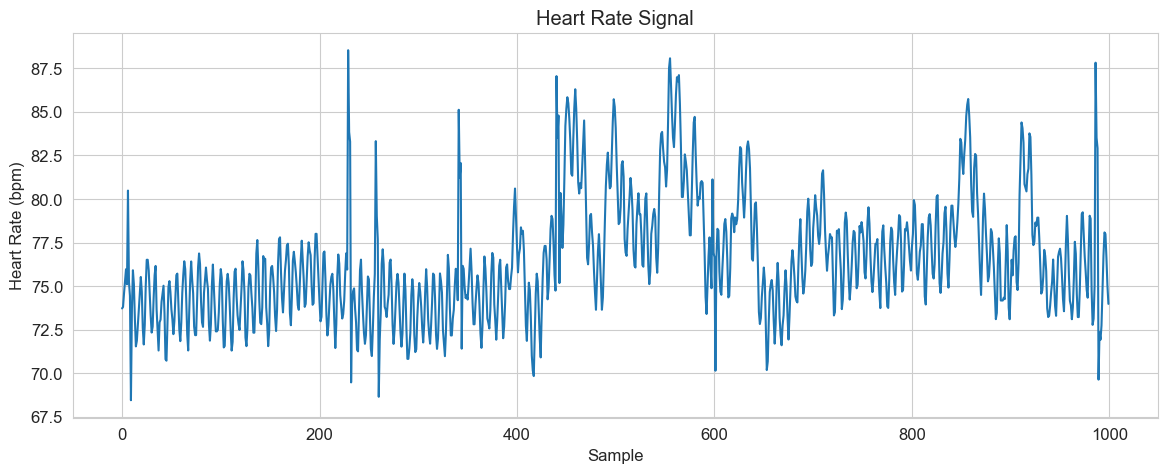

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(df['heart_rate'][:1000])

plt.title("Heart Rate Signal")

plt.xlabel("Sample")

plt.ylabel("Heart Rate (bpm)")

plt.show()

In [8]:
series = df['heart_rate'].values

train_size = int(
    len(series) * (1 - TEST_SIZE)
)

train = series[:train_size]

test = series[train_size:]

print("Train size:", len(train))
print("Test size :", len(test))

Train size: 1591
Test size : 682


In [9]:
def evaluate_model(
    y_true,
    y_pred,
    model_name
):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

In [12]:
ar_model = AutoReg(
    train,
    lags=5
).fit()

ar_pred = ar_model.predict(
    start=len(train),
    end=len(train) + len(test) - 1,
    dynamic=False
)

print("AR model completed")

AR model completed


In [10]:
ma_model = ARIMA(
    train,
    order=(0, 0, 5)
).fit()

ma_pred = ma_model.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

print("MA model completed")

MA model completed


In [13]:
arma_model = ARIMA(
    train,
    order=(5, 0, 5)
).fit()

arma_pred = arma_model.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

print("ARMA model completed")

ARMA model completed


In [14]:
arima_model = ARIMA(
    train,
    order=(5, 1, 5)
).fit()

arima_pred = arima_model.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

print("ARIMA model completed")

ARIMA model completed


In [15]:
sarima_model = SARIMAX(
    train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 12)
).fit(disp=False)

sarima_pred = sarima_model.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

print("SARIMA model completed")

SARIMA model completed


In [16]:
results = []

results.append(
    evaluate_model(
        test,
        ar_pred,
        "AR"
    )
)

results.append(
    evaluate_model(
        test,
        ma_pred,
        "MA"
    )
)

results.append(
    evaluate_model(
        test,
        arma_pred,
        "ARMA"
    )
)

results.append(
    evaluate_model(
        test,
        arima_pred,
        "ARIMA"
    )
)

results.append(
    evaluate_model(
        test,
        sarima_pred,
        "SARIMA"
    )
)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='RMSE'
)

results_df

,Model,RMSE,MAE,R2
0,AR,3.539389,2.727805,-0.016780
1,MA,3.544333,2.716786,-0.019622
2,ARMA,3.571152,2.785594,-0.035111
3,ARIMA,4.053658,3.509108,-0.333720
4,SARIMA,4.385315,3.890063,-0.560888


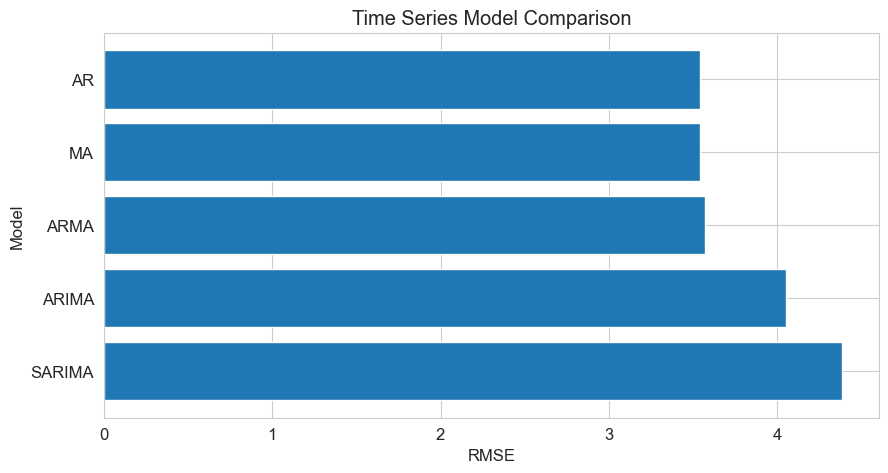

In [18]:
plt.figure(figsize=(10, 5))

plt.barh(
    results_df['Model'],
    results_df['RMSE']
)

plt.xlabel("RMSE")

plt.ylabel("Model")

plt.title("Time Series Model Comparison")

plt.gca().invert_yaxis()

plt.show()